# Resonance & Connectivity Cookbook

A practical tour of `biotuner.resonance`, `biotuner.harmonic_spectrum`, and
`biotuner.harmonic_connectivity` — the three modules that together cover
single-signal harmonic analysis and cross-channel connectivity.

This notebook walks through ten workflow categories:

1. **Setup** — synthetic signals + strategy discovery
2. **H-only spectrum** — `compute_harmonic_spectrum`
3. **Full single-signal R(f)** — `compute_resonance`, and why surrogate
   normalization is needed for `H ≠ PC ≠ R` discrimination
4. **Swapping kernels** — harmonic kernel
5. **Swapping coupling metrics** — including the n:m convention rule, with a
   cross-channel example that visibly separates PLV from PLI/wPLI
6. **Swapping ratio kernels** — `binary` vs `fraction`, with a 10:17
   mode-lock that only the fraction kernel can test
7. **Swapping combine rules** — with H and PC peaks at different bins
8. **Surrogate-null normalization** — `with_surrogate_null`
9. **Cross-channel resonance** — `compute_cross_resonance`, 3 reducer flavors
10. **Connectivity matrices + statistical inference**

The cells are self-contained — each section can be run independently after
the "Setup" block has been executed.


## 1. Setup

Imports + small helpers + synthetic-signal generators.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# biotuner.resonance — single-signal H × PC = R machinery
from biotuner.resonance import (
    compute_resonance, ResonanceConfig, ResonanceResult,
    with_surrogate_null, list_strategies, results_to_dataframe,
)

# biotuner.harmonic_spectrum — narrow H-only entry point
from biotuner.harmonic_spectrum import compute_harmonic_spectrum

# biotuner.harmonic_connectivity — cross-channel APIs
from biotuner.harmonic_connectivity import (
    harmonic_connectivity, compute_cross_resonance, CrossResonanceResult,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "lines.linewidth": 1.4,
                      "axes.spines.top": False, "axes.spines.right": False})


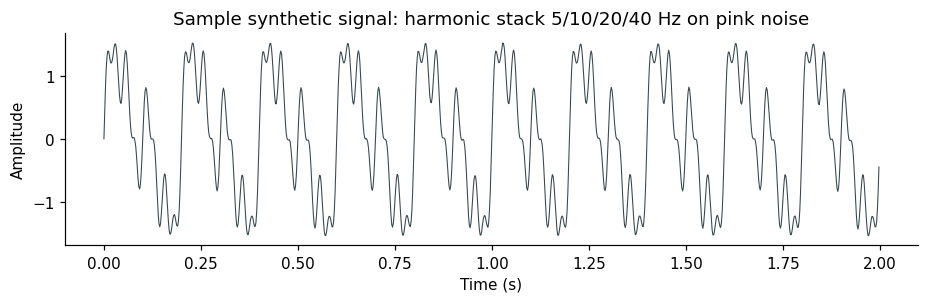

In [2]:
SF = 500   # sampling frequency for all examples

def pink_noise(n, sf, seed=0):
    rng = np.random.default_rng(seed)
    w = rng.standard_normal(n)
    f = np.fft.rfftfreq(n, 1/sf); f[0] = f[1]
    return np.fft.irfft(np.fft.rfft(w) / np.sqrt(f), n=n)

def harmonic_signal(sf=SF, duration=8.0, freqs=(5, 10, 20, 40), amp_decay=0.7, seed=0):
    """Phase-locked harmonic stack of sinusoids on pink-noise background."""
    t = np.arange(int(sf * duration)) / sf
    sig = sum((amp_decay ** i) * np.sin(2 * np.pi * f * t) for i, f in enumerate(freqs))
    sig += 0.05 * pink_noise(len(t), sf, seed=seed)
    return sig

def alpha_burst_signal(sf=SF, duration=8.0, alpha_freq=10.0, n_bursts=6, seed=0):
    """EEG-like: 1/f background + Hann-windowed alpha bursts."""
    rng = np.random.default_rng(seed)
    n = int(sf * duration); t = np.arange(n) / sf
    sig = 1.0 * pink_noise(n, sf, seed=seed)
    burst_times = np.linspace(0.5, duration - 1.0, n_bursts) + rng.uniform(-0.1, 0.1, size=n_bursts)
    for bt in burst_times:
        idx = (t >= bt) & (t <= bt + 0.6)
        local = t[idx] - bt
        win = np.sin(np.pi * local / 0.6) ** 2
        sig[idx] += 2.0 * win * np.sin(2 * np.pi * alpha_freq * local + rng.uniform(0, 2 * np.pi))
    return sig

def detuned_pair_signal(sf=SF, duration=30.0, seed=0):
    """Two pairs that both LOOK like 1:2 harmonic stacks in the PSD, but
    only one is actually phase-locked:

      * 6 + 12 Hz — EXACT 1:2 ratio, phase-locked (high H, high PC, high R)
      * 9 + 18.5 Hz — slightly detuned (18.5/9 = 2.056 within binary's 5%
        tolerance, so H still sees it as 1:2) but the real phase relation
        drifts (low PC, low R)

    Pedagogical lesson: H reflects PSD shape; only the surrogate-z-scored
    R distinguishes real coupling from same-PSD impostors.
    """
    rng = np.random.default_rng(seed)
    n = int(sf * duration); t = np.arange(n) / sf
    phi = 2 * np.pi * 6 * t + 0.3
    locked = 1.2 * np.sin(phi) + 0.8 * np.sin(2 * phi + 0.4)
    detuned = (1.2 * np.sin(2 * np.pi * 9.0 * t + rng.uniform(0, 2 * np.pi))
               + 0.8 * np.sin(2 * np.pi * 18.5 * t + rng.uniform(0, 2 * np.pi)))
    lone = 0.7 * np.sin(2 * np.pi * 23 * t + 1.7)
    bg = 0.15 * pink_noise(n, sf, seed=seed + 99)
    return locked + detuned + lone + bg

def coupled_channels(sf=SF, duration=12.0, mode='lagged', seed=0):
    """Two channels coupled at 10 Hz under three coupling regimes:

      mode='zero_lag' : φ_A = φ_B exactly (volume-conduction artifact)
      mode='lagged'   : φ_B = φ_A + π/3 (genuine lagged coupling)
      mode='uncoupled': independent random phases (no coupling)

    Use this to compare phase-coupling metrics — PLV detects all three
    locked cases, PLI/wPLI suppress the zero-lag one.
    """
    rng = np.random.default_rng(seed)
    n = int(sf * duration); t = np.arange(n) / sf
    phi = 2 * np.pi * 10 * t
    sig_a = np.sin(phi) + 0.3 * pink_noise(n, sf, seed=seed + 1)
    if mode == 'zero_lag':
        sig_b = np.sin(phi) + 0.3 * pink_noise(n, sf, seed=seed + 2)
    elif mode == 'lagged':
        sig_b = np.sin(phi + np.pi / 3) + 0.3 * pink_noise(n, sf, seed=seed + 2)
    elif mode == 'uncoupled':
        # Random-walk phase: φ_B drifts independently — same PSD peak at 10 Hz,
        # but the phase relation to φ_A is destroyed over time.
        dphi = rng.standard_normal(n) * 1.0 * np.sqrt(1.0 / sf)
        sig_b = (np.sin(2 * np.pi * 10 * t + np.cumsum(dphi))
                 + 0.3 * pink_noise(n, sf, seed=seed + 2))
    else:
        raise ValueError(mode)
    return sig_a, sig_b

# Display a sample signal
sig = harmonic_signal()
fig, ax = plt.subplots(figsize=(10, 2.5))
t = np.arange(len(sig))/SF
ax.plot(t[:int(SF*2)], sig[:int(SF*2)], color='#37474f', lw=0.7)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Amplitude")
ax.set_title("Sample synthetic signal: harmonic stack 5/10/20/40 Hz on pink noise")
plt.show()


### 1b. Discovery: what strategies are available?

`list_strategies()` prints every registered kernel, coupling metric, combine
rule, etc. All names returned are valid for the corresponding
`ResonanceConfig` field.


In [3]:
list_strategies()


HARMONIC_KERNELS (2)
  - harmsim
  - subharm_tension

RATIO_KERNELS (2)
  - binary
  - fraction

PHASE_ESTIMATORS (1)
  - stft

PAIRWISE_COUPLING_METRICS (6)
  - nm_pli  [phase]
  - nm_plv  [phase]
  - nm_plv_canonical  [phase]
  - nm_rrci  [phase]
  - nm_wpli  [phase]
  - nm_wpli_complex  [analytic]

HIGHER_ORDER_COUPLING_METHODS (0)
  (none — see plan §5 for the Phase 2/3 additions)

PERSISTENCE_METHODS (0)
  (none — see plan §5 for the Phase 2/3 additions)

COMBINE_RULES (5)
  - geomean
  - harmmean
  - min
  - product
  - weighted_log

SURROGATE_TYPES (0)
  (none — see plan §5 for the Phase 2/3 additions)



{'HARMONIC_KERNELS': {'harmsim': <function biotuner.resonance.kernels_harmonic.kernel_harmsim(freqs_i: numpy.ndarray, freqs_j: numpy.ndarray, *, diagonal: float = None, **_unused) -> numpy.ndarray>,
  'subharm_tension': <function biotuner.resonance.kernels_harmonic.kernel_subharm_tension(freqs_i: numpy.ndarray, freqs_j: numpy.ndarray, *, n_harms: int = 10, delta_lim: float = 20, min_notes: int = 2, diagonal: float = None, **_unused) -> numpy.ndarray>},
 'RATIO_KERNELS': {'binary': <function biotuner.resonance.kernels_ratio.binary_nm_kernel(freqs_i: numpy.ndarray, freqs_j: numpy.ndarray, *, max_nm: int = 3, tolerance: float = 0.05, fallback_to_1_1: bool = True, **_unused)>,
  'fraction': <function biotuner.resonance.kernels_ratio.fraction_kernel(freqs_i: numpy.ndarray, freqs_j: numpy.ndarray, *, max_denom: int = 16, beta: float = 1.0, **_unused)>},
 'PHASE_ESTIMATORS': {'stft': <function biotuner.resonance.phase_estimators.stft_phase(signal: numpy.ndarray, sf: float, *, precision_hz: fl

## 2. H-only spectrum (single signal)

For just the harmonicity factor H(f) — without the full PC and R computation —
use `compute_harmonic_spectrum`. Returns the spectrum plus a rich complexity
summary dict.


H shape: (57,)
S (kernel matrix) shape: (57, 57)
summary keys: ['avg', 'entropy', 'flatness', 'higuchi', 'max', 'peak_harmsim', 'peak_harmsim_avg', 'peak_harmsim_max', 'peak_indices', 'peaks', 'peaks_avg', 'spread']
flatness: 0.7614612776395674
entropy: 5.358903605652942
peaks: [ 5. 10. 20.]


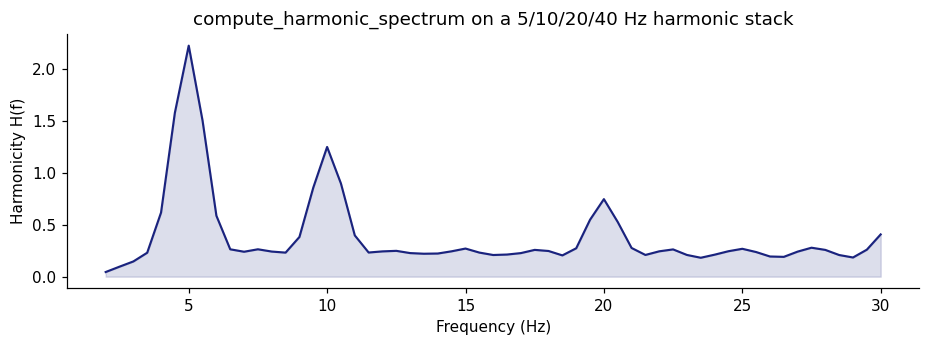

In [4]:
sig = harmonic_signal()

freqs, H, S, summary = compute_harmonic_spectrum(
    sig, precision_hz=0.5, fmin=2, fmax=30, fs=SF,
)

print("H shape:", H.shape)
print("S (kernel matrix) shape:", S.shape)
print("summary keys:", sorted(summary.keys()))
print("flatness:", summary['flatness'])
print("entropy:", summary['entropy'])
print("peaks:", summary['peaks'])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(freqs, H, color='#1a237e')
ax.fill_between(freqs, 0, H, color='#1a237e', alpha=0.15)
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Harmonicity H(f)")
ax.set_title("compute_harmonic_spectrum on a 5/10/20/40 Hz harmonic stack")
plt.show()


## 3. Full single-signal resonance R = H × PC

`compute_resonance` runs the full pipeline: harmonic kernel → ratio kernel →
phase estimator → coupling metric → reducers → combine.

### Important caveat: H, PC, R correlate by construction

Both H(f) and PC(f) are PSD-weighted in the orchestrator:

```
H(f)  = p(f) · Σⱼ S[f, j] · p(j)
PC(f) = p(f) · Σⱼ W[f, j] · Φ[f, j] · p(j)
```

So **wherever PSD has a peak, both factors get amplified together** — the
raw spectra tend to share peak locations, just with different relative
heights. To see whether peaks reflect *real* harmonic coupling vs broadband
power, use surrogate normalization (Section 8) or compare against the same
signal's IAAFT-z-scored R.

We demonstrate this with the `detuned_pair_signal`, designed so the
9 + 18.5 Hz pair has nearly-identical PSD to the locked 6 + 12 Hz pair but
NO actual phase coupling.


In [5]:
sig = detuned_pair_signal(duration=30.0)
cfg = ResonanceConfig(precision_hz=0.5, fmin=2, fmax=30, noverlap=900)
result = compute_resonance(sig, sf=SF, config=cfg)

print("type:", type(result).__name__)
print("freqs shape:", result.freqs.shape)
print("factors:", list(result.factors.keys()))
print("peaks:", result.peaks)
print()
print("Note that both H and PC peak at the 'detuned' site 9 Hz, not just")
print("the truly phase-locked site 6 Hz — this is the PSD-weighting effect.")
print()
print("Summaries (complexity per spectrum):")
for k, s in result.summaries.items():
    print(f"  {k}: flatness={s['flatness']:.3f}  entropy={s['entropy']:.3f}  "
          f"avg={s['avg']:.3g}")


type: ResonanceResult
freqs shape: (57,)
factors: ['H', 'PC']
peaks: {'H': array([ 6.,  9., 12.]), 'PC': array([ 6. ,  9. , 18.5, 23. , 12. ]), 'R': array([ 6. ,  9. , 12. , 18.5, 23. ])}

Note that both H and PC peak at the 'detuned' site 9 Hz, not just
the truly phase-locked site 6 Hz — this is the PSD-weighting effect.

Summaries (complexity per spectrum):
  H: flatness=0.678  entropy=5.244  avg=0.355
  PC: flatness=0.658  entropy=5.305  avg=0.00136
  R: flatness=0.229  entropy=4.091  avg=0.000941


In [6]:
# Getting different views of the result — the public API
print("Reduced 1-D spectra (length n_freqs):")
print(f"  result.factors['H'].shape          = {result.factors['H'].shape}")
print(f"  result.factors['PC'].shape         = {result.factors['PC'].shape}")
print(f"  result.resonance_spectrum.shape    = {result.resonance_spectrum.shape}")
print()
print("Per-spectrum scalar metrics (legacy compute_global_harmonicity columns):")
for k in ['H', 'PC', 'R']:
    s = result.summaries[k]
    print(f"  result.summaries[{k!r}]: avg={s['avg']:.3g}  max={s['max']:.3g}  "
          f"flatness={s['flatness']:.3f}  entropy={s['entropy']:.3f}  "
          f"spread={s['spread']:.3f}  peaks_avg={s['peaks_avg']:.2f}")
print()
print("Peak frequencies per spectrum:")
for k in ['H', 'PC', 'R']:
    print(f"  result.peaks[{k!r}] = {result.peaks[k]}")
print()
print("To get a flat pandas DataFrame across multiple results (legacy layout):")
print("  from biotuner.resonance import results_to_dataframe")
print("  df = results_to_dataframe([result, ...])   # 41 columns")
print()
print("Full N x N matrices (need return_intermediates=True on the config):")
print(f"  result.harmonicity_matrix   - raises AttributeError when not opted in,")
print(f"                                else (n_freqs, n_freqs) S[i, j]")
print(f"  result.phase_coupling_matrix - same, Phi[i, j]")


Reduced 1-D spectra (length n_freqs):
  result.factors['H'].shape          = (57,)
  result.factors['PC'].shape         = (57,)
  result.resonance_spectrum.shape    = (57,)

Per-spectrum scalar metrics (legacy compute_global_harmonicity columns):
  result.summaries['H']: avg=0.355  max=1.87  flatness=0.678  entropy=5.244  spread=7.169  peaks_avg=9.00
  result.summaries['PC']: avg=0.00136  max=0.00619  flatness=0.658  entropy=5.305  spread=7.314  peaks_avg=13.70
  result.summaries['R']: avg=0.000941  max=0.0116  flatness=0.229  entropy=4.091  spread=5.566  peaks_avg=13.70

Peak frequencies per spectrum:
  result.peaks['H'] = [ 6.  9. 12.]
  result.peaks['PC'] = [ 6.   9.  18.5 23.  12. ]
  result.peaks['R'] = [ 6.   9.  12.  18.5 23. ]

To get a flat pandas DataFrame across multiple results (legacy layout):
  from biotuner.resonance import results_to_dataframe
  df = results_to_dataframe([result, ...])   # 41 columns

Full N x N matrices (need return_intermediates=True on the config):
 

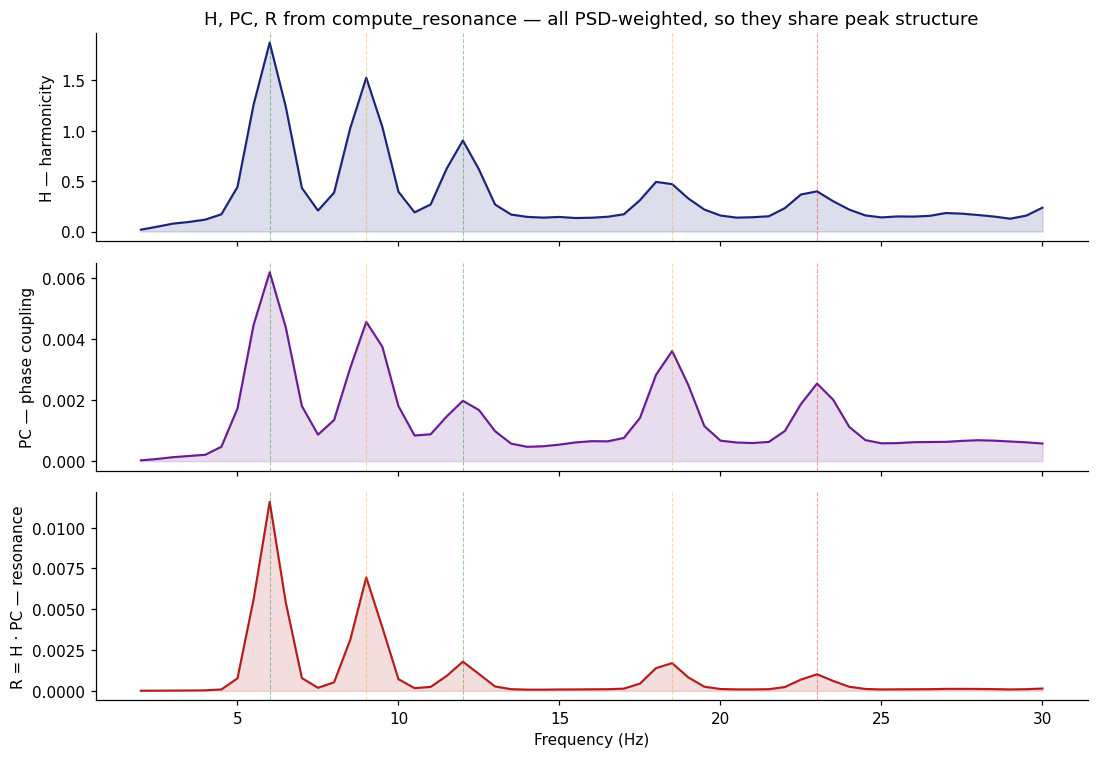


Shape correlations (peak-aligned across spectra):
  H ~ PC = 0.933
  H ~ R  = 0.952
  PC ~ R = 0.907

Both H and PC are PSD-weighted in the orchestrator (Step 9 reducer:
v[i] = p[i] * sum_j M[i,j] * p[j]), so wherever PSD peaks, both factors
are amplified. To distinguish TRUE phase coupling from PSD-impostors,
use surrogate normalization (Section 8) — AAFT/IAAFT surrogates preserve
PSD but destroy phase relations, so the z-scored R isolates pure coupling.


In [7]:
freqs = result.freqs
H = result.factors['H']; PC = result.factors['PC']; R = result.resonance_spectrum

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, (name, vals, color) in zip(axes, [
    ('H — harmonicity',           H,  '#1a237e'),
    ('PC — phase coupling',       PC, '#6a1b9a'),
    ('R = H · PC — resonance',    R,  '#b71c1c'),
]):
    ax.plot(freqs, vals, color=color)
    ax.fill_between(freqs, 0, vals, color=color, alpha=0.15)
    ax.set_ylabel(name)
    for tgt, lbl, col in [(6, '6 (locked)', 'green'),
                            (9, '9 (detuned)', 'orange'),
                            (12, '12 (locked)', 'green'),
                            (18.5, '18.5 (detuned)', 'orange'),
                            (23, '23 (lone)', 'red')]:
        ax.axvline(tgt, color=col, alpha=0.4, lw=0.7, ls='--')

axes[-1].set_xlabel("Frequency (Hz)")
axes[0].set_title("H, PC, R from compute_resonance — all PSD-weighted, so they share peak structure")
plt.tight_layout(); plt.show()

# Quantify how similar H/PC/R shapes are (Pearson correlation, normalized to max)
print()
def corr(a, b): return float(np.corrcoef(a/a.max(), b/b.max())[0, 1])
print("Shape correlations (peak-aligned across spectra):")
print(f"  H ~ PC = {corr(H, PC):.3f}")
print(f"  H ~ R  = {corr(H, R):.3f}")
print(f"  PC ~ R = {corr(PC, R):.3f}")
print()
print("Both H and PC are PSD-weighted in the orchestrator (Step 9 reducer:")
print("v[i] = p[i] * sum_j M[i,j] * p[j]), so wherever PSD peaks, both factors")
print("are amplified. To distinguish TRUE phase coupling from PSD-impostors,")
print("use surrogate normalization (Section 8) — AAFT/IAAFT surrogates preserve")
print("PSD but destroy phase relations, so the z-scored R isolates pure coupling.")


## 4. Swapping harmonic kernels

Two harmonic kernels are registered: `harmsim` (Gill-Purves dyad similarity)
and `subharm_tension` (Chan subharmonic tension, inverted). They give
qualitatively similar peak structure but differ in absolute magnitude and how
strongly they penalize complex ratios.


C:\Users\skite\Documents\Github\biotuner\.claude\worktrees\sweet-hamilton-6c0f0d\biotuner\metrics.py:954: RuntimeWarning: divide by zero encountered in scalar divide
  harm_temp.append(1 / delta_norm)


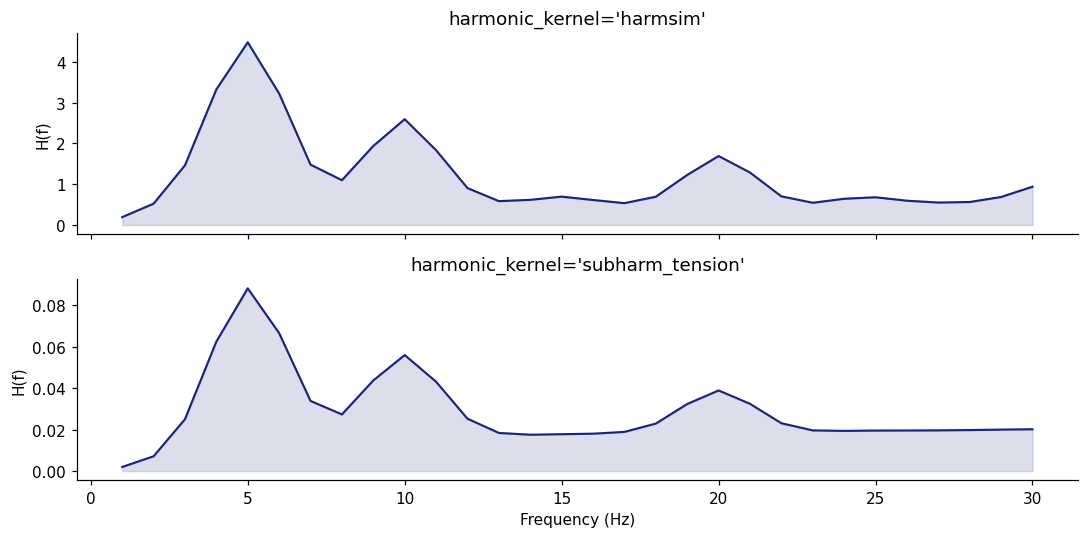

In [8]:
sig = harmonic_signal()

results = {}
for kernel in ['harmsim', 'subharm_tension']:
    cfg = ResonanceConfig(harmonic_kernel=kernel)
    results[kernel] = compute_resonance(sig, sf=SF, config=cfg)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for ax, (kernel, r) in zip(axes, results.items()):
    ax.plot(r.freqs, r.factors['H'], color='#1a237e', label='H(f)')
    ax.fill_between(r.freqs, 0, r.factors['H'], color='#1a237e', alpha=0.15)
    ax.set_title(f"harmonic_kernel='{kernel}'")
    ax.set_ylabel('H(f)')
axes[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout(); plt.show()


## 5. Coupling metrics — and the n:m convention rule

Six pairwise metrics are registered, falling into two input-type categories:

- **`phase` inputs**: `nm_plv`, `nm_pli`, `nm_wpli`, `nm_rrci`, `nm_plv_canonical`.
- **`analytic` inputs**: `nm_wpli_complex`.

### Important: convention rule

All ratio kernels in biotuner (`binary`, `fraction`, future Arnold-tongue)
return `(n, m)` with the convention `ratio = f_j / f_i = m / n`. The plain
`nm_plv` applies this as `n·φ_i − m·φ_j`, which is mathematically wrong for
true n:m phase locking under Tass 1998. **For correct n:m phase-coupling
tests, use `coupling_metric='nm_plv_canonical'`** — it swaps `(n, m)`
internally to apply the Tass formula. `nm_plv` is kept for **bit-exact
reproduction** of legacy paper analyses only.

### Where do these metrics actually differ?

For long, clean, single-signal data, all phase-input metrics give similar
PC shapes (because they all measure the same underlying STFT phase
coherence, just with different rejection of common-mode components). To
see the **theoretical** differences cleanly, apply the metrics directly to
synthesized phase arrays representing three canonical coupling regimes:


In [9]:
from biotuner.resonance.coupling import nm_plv, nm_pli, nm_wpli, nm_plv_canonical, nm_rrci

# Synthesize per-window phase arrays under three canonical coupling regimes
rng = np.random.default_rng(0)
N = 5000
phi_a = 2 * np.pi * rng.random(N)

regimes = {
    'zero_lag (0)':       phi_a.copy(),                          # identical phases
    'lagged (pi/3)':      phi_a + np.pi / 3,                     # constant offset
    'anti_phase (pi)':    phi_a + np.pi,                         # anti-aligned
    'noisy_lag':          phi_a + np.pi / 3 + 0.6 * rng.standard_normal(N),
    'uncoupled':          2 * np.pi * rng.random(N),             # independent
}

metrics = {
    'PLV':              nm_plv,
    'PLV_canonical':    nm_plv_canonical,
    'PLI':              nm_pli,
    'wPLI':             nm_wpli,
    'RRCi':             nm_rrci,
}

# Compute and tabulate
print(f"{'regime':<22}  " + "  ".join(f"{name:>14}" for name in metrics))
print("-" * (22 + len(metrics) * 16))
results = {}
for regime, phi_b in regimes.items():
    row = {}
    for mname, mfn in metrics.items():
        row[mname] = mfn(phi_a, phi_b, 1, 1)
    results[regime] = row
    print(f"{regime:<22}  " + "  ".join(f"{row[n]:>14.4f}" for n in metrics))
print()
print("Key observations:")
print("  PLV peaks for zero_lag AND lagged (it sees ALL constant phase relations)")
print("  PLI/wPLI ~ 0 for zero_lag and anti_phase (sin(Delta phi) = 0)")
print("  PLI/wPLI peak for lagged (Delta phi = pi/3 gives nonzero imag part)")
print("  All metrics ~ 0 for uncoupled (random phase difference)")


regime                             PLV   PLV_canonical             PLI            wPLI            RRCi
------------------------------------------------------------------------------------------------------
zero_lag (0)                    1.0000          1.0000          0.0000          0.0000          0.0000
lagged (pi/3)                   1.0000          1.0000          1.0000          1.0000          0.8660
anti_phase (pi)                 1.0000          1.0000          0.6708          0.0000          0.0000
noisy_lag                       0.8343          0.8343          0.9196          0.9708          0.7286
uncoupled                       0.0081          0.0081          0.0024          0.0069          0.0044

Key observations:
  PLV peaks for zero_lag AND lagged (it sees ALL constant phase relations)
  PLI/wPLI ~ 0 for zero_lag and anti_phase (sin(Delta phi) = 0)
  PLI/wPLI peak for lagged (Delta phi = pi/3 gives nonzero imag part)
  All metrics ~ 0 for uncoupled (random phase diffe

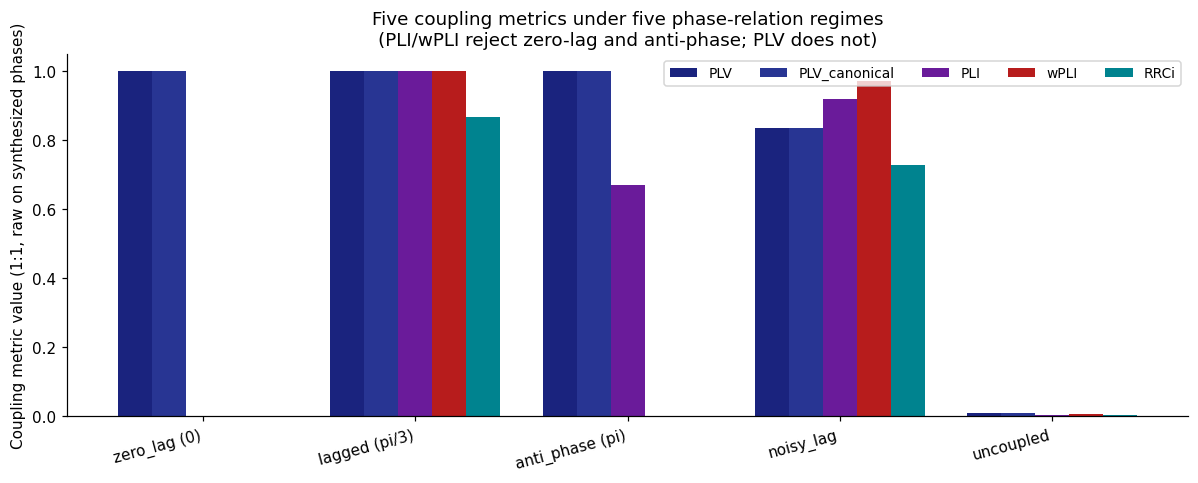

In [10]:
# Grouped bar plot of the same table
fig, ax = plt.subplots(figsize=(11, 4.5))
regime_names = list(regimes)
x = np.arange(len(regime_names))
width = 0.16
colors = ['#1a237e', '#283593', '#6a1b9a', '#b71c1c', '#00838f']
for i, (mname, color) in enumerate(zip(metrics, colors)):
    vals = [results[r][mname] for r in regime_names]
    ax.bar(x + (i - len(metrics)/2 + 0.5) * width, vals, width, label=mname, color=color)
ax.set_xticks(x); ax.set_xticklabels(regime_names, rotation=15, ha='right')
ax.set_ylabel("Coupling metric value (1:1, raw on synthesized phases)")
ax.set_title("Five coupling metrics under five phase-relation regimes\n"
              "(PLI/wPLI reject zero-lag and anti-phase; PLV does not)")
ax.legend(loc='upper right', ncols=5, fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()


## 6. Ratio kernels — `binary` (legacy) vs `fraction` (new)

The ratio kernel decides which `(n, m)` integer pair to test at each frequency
pair, and how heavily to weight the result.

- **`binary`** — iterates `1 ≤ n, m ≤ max_nm` (default 3), picks the best
  match within 5% tolerance. Returns W=1 if matched, W=0 otherwise — or
  `(n=1, m=1)` if `fallback_to_1_1=True`. **Misses any ratio outside the
  small preset table.**
- **`fraction`** — computes `Fraction(f_j / f_i).limit_denominator(max_denom)`
  to find the EXACT closest rational. Weights via Tenney height
  `W = exp(-β · log₂(n·m))`, so simple ratios dominate but complex ones can
  still be tested.

### Demonstration: a 10 + 17 Hz phase-locked signal

`17 / 10 = 1.7` matches no integer ratio with `n, m ≤ 3`, so `binary` falls
back to 1:1 (testing a meaningless 10:10 coupling at the 10/17 bin pair).
`fraction` returns `(n=10, m=17)` — the actual mode-lock — though heavily
down-weighted by Tenney height.


In [11]:
# Build a 10:17 phase-locked signal
def lock_signal_1017(sf=SF, duration=30.0, seed=0):
    n = int(sf * duration); t = np.arange(n) / sf
    phi_unit = 2 * np.pi * 1.0 * t  # common subharmonic
    # 10 Hz and 17 Hz share the same 1 Hz base phase — true 10:17 lock
    sig = (np.sin(10 * phi_unit) + 0.7 * np.sin(17 * phi_unit + 0.3)
           + 0.15 * pink_noise(n, sf, seed=seed))
    return sig

sig_1017 = lock_signal_1017()

print("Ratio kernel comparison at the 10 Hz peak:")
print(f"{'kernel':<10}  {'PC(10)':>8}  {'PC(17)':>8}  {'(n, m) at (10, 17)':<22}")
print("-" * 60)

import numpy as _np
for kernel_name, kernel_params in [
    ('binary',  {'max_nm': 3, 'tolerance': 0.05, 'fallback_to_1_1': True}),
    ('fraction', {'max_denom': 32, 'beta': 0.5}),
]:
    cfg = ResonanceConfig(
        precision_hz=0.5, fmin=2, fmax=30, noverlap=900,
        ratio_kernel=kernel_name,
        ratio_kernel_params=kernel_params,
        coupling_metric='nm_plv_canonical',  # always pair with canonical
    )
    r = compute_resonance(sig_1017, sf=SF, config=cfg)
    i10 = int(_np.argmin(_np.abs(r.freqs - 10)))
    i17 = int(_np.argmin(_np.abs(r.freqs - 17)))

    # Probe what (n, m) the kernel actually returned at (10, 17)
    from biotuner.resonance.registry import RATIO_KERNELS
    W, N, M = RATIO_KERNELS[kernel_name](_np.array([10.0]), _np.array([17.0]),
                                          **kernel_params)
    nm_str = f"n={int(N[0,0])}, m={int(M[0,0])}, W={W[0,0]:.3f}"

    print(f"{kernel_name:<10}  {r.factors['PC'][i10]:>8.4f}  {r.factors['PC'][i17]:>8.4f}  {nm_str}")

print()
print("Reading: binary maps (10, 17) -> (n=1, m=1) — a spurious 1:1 test that")
print("contaminates the PC sum with whatever bins look 1:1 to 10 Hz.")
print("fraction maps (10, 17) -> (n=10, m=17) — the TRUE mode-lock — with a")
print("small Tenney weight reflecting how complex the ratio is.")


Ratio kernel comparison at the 10 Hz peak:
kernel        PC(10)    PC(17)  (n, m) at (10, 17)    
------------------------------------------------------------
binary        0.0249    0.0080  n=1, m=1, W=1.000


fraction      0.0003    0.0002  n=10, m=17, W=0.025

Reading: binary maps (10, 17) -> (n=1, m=1) — a spurious 1:1 test that
contaminates the PC sum with whatever bins look 1:1 to 10 Hz.
fraction maps (10, 17) -> (n=10, m=17) — the TRUE mode-lock — with a
small Tenney weight reflecting how complex the ratio is.


## 7. Combine rules — H × PC → R

Five combine rules. Default `product` (R = H · PC) is the legacy semantics.

For typical signals from `compute_resonance` (where H and PC are
PSD-weighted and end up with similar shapes), the five combine rules
look very similar to each other. To make their differences visible, we
construct a synthetic `(H_arr, PC_arr)` pair where peaks live at DIFFERENT
bins, and apply each combine rule directly.


Peaks: H at 8 & 15 ; PC at 15 & 22.
Combine rules respond DIFFERENTLY to non-overlapping peaks:



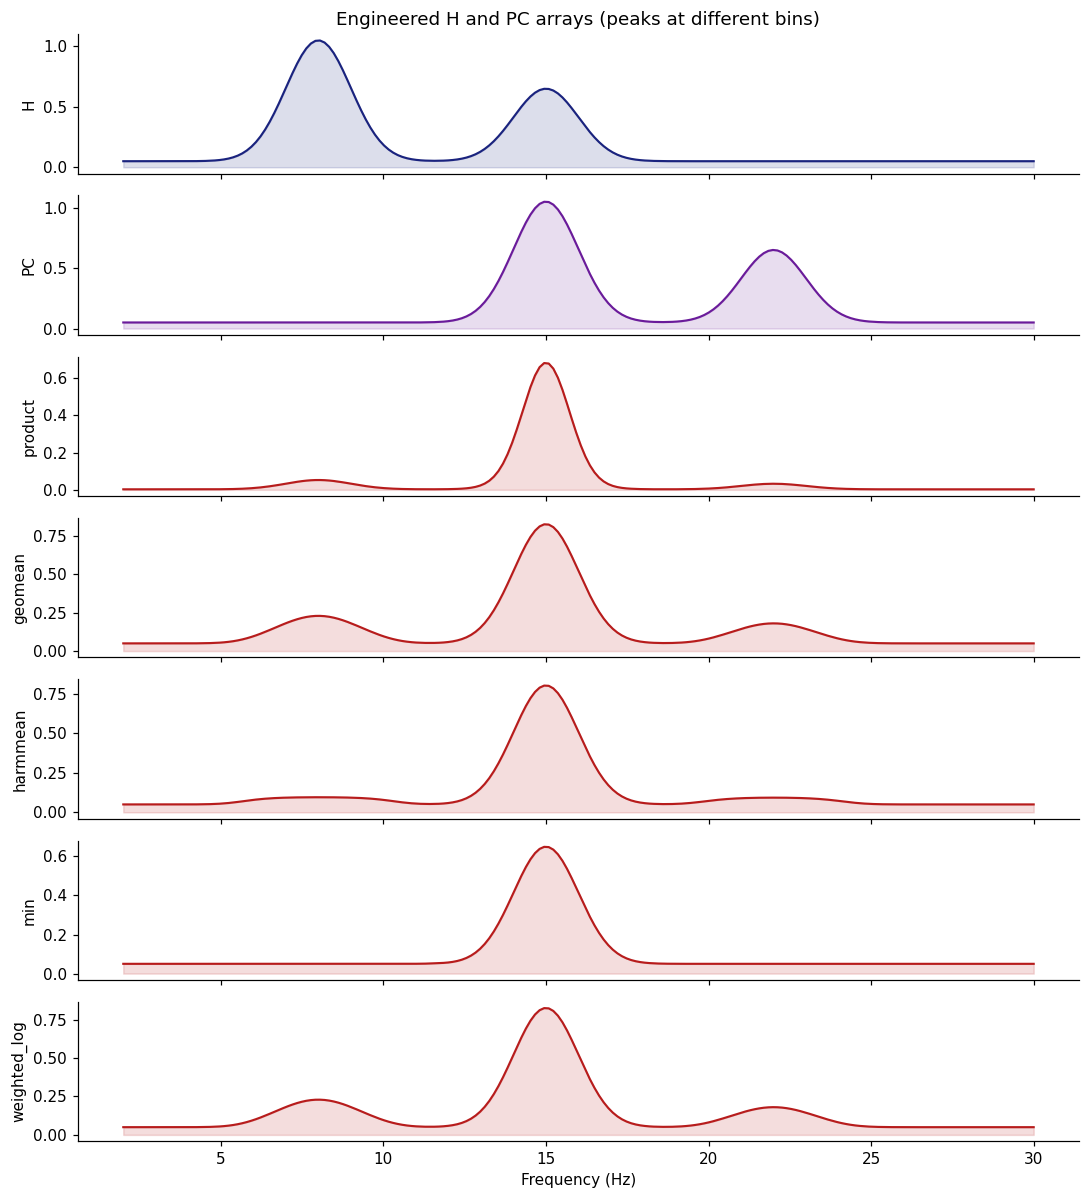


Peak frequency of R(f) per rule:
  product          14.94 Hz
  geomean          14.94 Hz
  harmmean         14.94 Hz
  min              14.94 Hz
  weighted_log     14.94 Hz

'min' and 'harmmean' aggressively reject sites where one factor is small:
  peak settles at 15 (the only overlap).
'product'/'geomean' tilt toward 15 but preserve some signal at 8 (H high)
  and 22 (PC high). 'weighted_log' further amplifies asymmetry.


In [12]:
from biotuner.resonance.registry import COMBINE_RULES

# Construct H and PC with peaks at DIFFERENT frequencies on purpose
freqs = np.linspace(2, 30, 200)
def gauss(c, w, h): return h * np.exp(-((freqs - c) ** 2) / (2 * w ** 2))

H_arr  = gauss(8,  1.0, 1.0) + gauss(15, 1.0, 0.6) + 0.05      # peaks at 8, 15
PC_arr = gauss(15, 1.0, 1.0) + gauss(22, 1.0, 0.6) + 0.05      # peaks at 15, 22

print("Peaks: H at 8 & 15 ; PC at 15 & 22.")
print("Combine rules respond DIFFERENTLY to non-overlapping peaks:")
print()

fig, axes = plt.subplots(7, 1, figsize=(10, 11), sharex=True)
axes[0].plot(freqs, H_arr, color='#1a237e', label='H'); axes[0].fill_between(freqs, 0, H_arr, color='#1a237e', alpha=0.15)
axes[0].set_ylabel('H'); axes[0].set_title('Engineered H and PC arrays (peaks at different bins)')
axes[1].plot(freqs, PC_arr, color='#6a1b9a', label='PC'); axes[1].fill_between(freqs, 0, PC_arr, color='#6a1b9a', alpha=0.15)
axes[1].set_ylabel('PC')

for ax, rule_name in zip(axes[2:], ['product', 'geomean', 'harmmean', 'min', 'weighted_log']):
    rule = COMBINE_RULES[rule_name]
    R_arr = rule([H_arr, PC_arr])
    ax.plot(freqs, R_arr, color='#b71c1c')
    ax.fill_between(freqs, 0, R_arr, color='#b71c1c', alpha=0.15)
    ax.set_ylabel(rule_name)

axes[-1].set_xlabel("Frequency (Hz)")

# Annotate where each combine rule places its peak
peak_freqs = {}
for rule_name in ['product', 'geomean', 'harmmean', 'min', 'weighted_log']:
    R_arr = COMBINE_RULES[rule_name]([H_arr, PC_arr])
    peak_freqs[rule_name] = freqs[int(np.argmax(R_arr))]
plt.tight_layout(); plt.show()

print()
print("Peak frequency of R(f) per rule:")
for rule_name, pf in peak_freqs.items():
    print(f"  {rule_name:<15}  {pf:.2f} Hz")
print()
print("'min' and 'harmmean' aggressively reject sites where one factor is small:")
print("  peak settles at 15 (the only overlap).")
print("'product'/'geomean' tilt toward 15 but preserve some signal at 8 (H high)")
print("  and 22 (PC high). 'weighted_log' further amplifies asymmetry.")


## 8. Surrogate-null normalization

For statistical inference, `with_surrogate_null` runs the resonance pipeline
on the observed signal AND on `n` AAFT/phase-randomized surrogates, then
z-scores the observed against the surrogate distribution.

For a noisy alpha-burst signal, the surrogates destroy phase structure while
preserving PSD — so high z-scores at the alpha carrier are evidence of true
phase-locked alpha, not just elevated PSD.


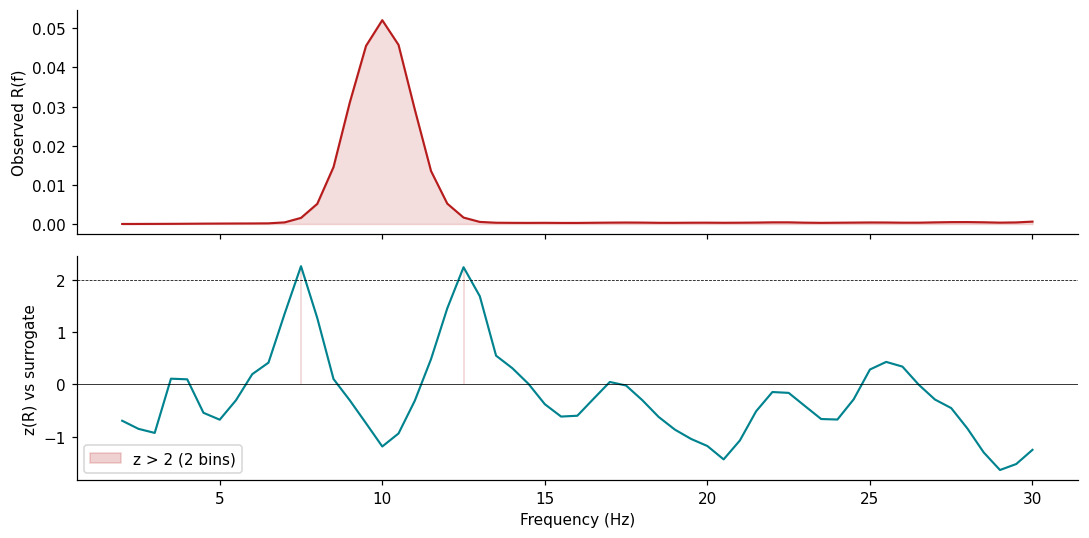

In [13]:
sig = alpha_burst_signal()

cfg = ResonanceConfig(precision_hz=0.5, fmin=2, fmax=30)
result_z = with_surrogate_null(
    sig, sf=SF, config=cfg, surr_type='AAFT', n=50, correction='both', parallel=False,
)

freqs = result_z.freqs
R = result_z.resonance_spectrum
z = result_z.resonance_spectrum_z

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(freqs, R, color='#b71c1c')
axes[0].fill_between(freqs, 0, R, color='#b71c1c', alpha=0.15)
axes[0].set_ylabel("Observed R(f)")

axes[1].plot(freqs, z, color='#00838f')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axhline(2, color='k', ls='--', lw=0.5)
sig_mask = z > 2
if sig_mask.any():
    axes[1].fill_between(freqs, 0, z, where=sig_mask, color='#b71c1c', alpha=0.2,
                          label=f"z > 2 ({sig_mask.sum()} bins)")
    axes[1].legend()
axes[1].set_ylabel("z(R) vs surrogate")
axes[1].set_xlabel("Frequency (Hz)")
plt.tight_layout(); plt.show()


## 9. Cross-channel resonance — `compute_cross_resonance`

The cross-channel analog of `compute_resonance`, for two signals. Returns a
`CrossResonanceResult` with **three reducer flavors** per factor:

- `'1to2'` — asymmetric (signal1 at i, signal2 at j)
- `'2to1'` — transposed
- `'all'` — symmetrized average

The three flavors expose directional information that the symmetric average
loses. We'll work through four progressively richer paired-channel cases.

### 9a. Four paired-channel scenarios

The same `compute_cross_resonance(sig1, sig2)` call applies to all of them —
only the input changes.


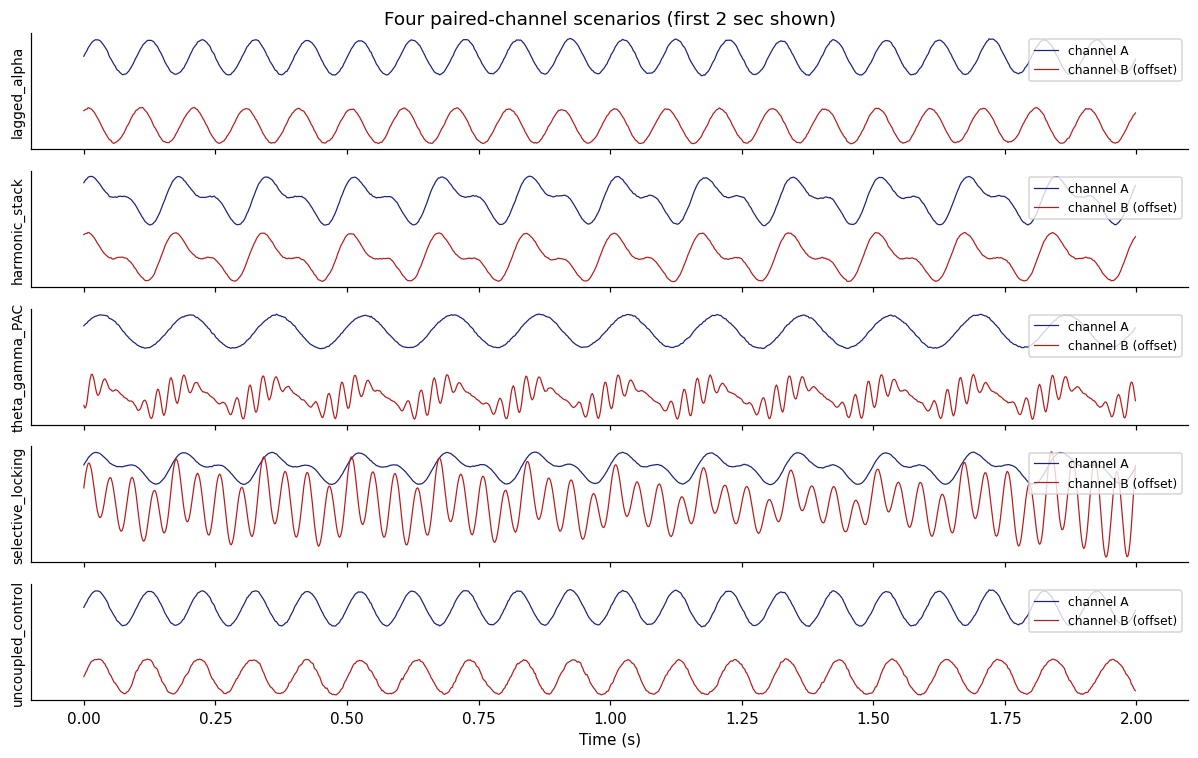

In [14]:
# Build four paired-channel datasets covering different coupling regimes.
SCENARIO_DUR = 12.0   # seconds
SCENARIO_T   = np.arange(int(SF * SCENARIO_DUR)) / SF

def _noise(seed, scale=0.2):
    return scale * pink_noise(len(SCENARIO_T), SF, seed=seed)

def alpha_lagged(seed=0):
    """Same 10 Hz in both channels, B lags A by pi/3. Simple lagged coupling."""
    t = SCENARIO_T
    phi = 2 * np.pi * 10 * t
    return np.sin(phi) + _noise(seed + 1), np.sin(phi + np.pi/3) + _noise(seed + 2)

def harmonic_stack_xchan(seed=0):
    """6+12 Hz phase-locked harmonic stack in both channels, B offset by pi/8.
    Rich harmonic coupling — H, PC, R all peak at both 6 and 12 Hz."""
    t = SCENARIO_T
    phi = 2 * np.pi * 6 * t + 0.4
    a = 1.2 * np.sin(phi) + 0.7 * np.sin(2 * phi + 0.3) + _noise(seed + 1)
    b = 1.2 * np.sin(phi + np.pi/8) + 0.7 * np.sin(2 * phi + 0.3 + np.pi/8) + _noise(seed + 2)
    return a, b

def theta_gamma_pac(seed=0):
    """Theta-gamma cross-frequency coupling.
    A: clean 6 Hz theta.
    B: 6 Hz theta + 40 Hz gamma amplitude-modulated by the theta phase
       (gamma is loudest at theta peaks). The two share a base frequency,
       but B carries an additional cross-frequency 6:40 amplitude lock."""
    t = SCENARIO_T
    rng = np.random.default_rng(seed)
    theta = np.sin(2 * np.pi * 6 * t + 0.3)
    a = theta + _noise(seed + 1)
    # gamma envelope follows theta amplitude (peaks at theta peaks)
    gamma_env = 0.5 * (1 + np.cos(2 * np.pi * 6 * t + 0.3))   # 0..1, locked to theta
    gamma = gamma_env * np.sin(2 * np.pi * 40 * t + rng.uniform(0, 2*np.pi))
    b = 0.7 * theta + 1.0 * gamma + _noise(seed + 2)
    return a, b

def uncoupled_control(seed=0):
    """Independent 10 Hz oscillators with random-walk phase drift in B."""
    t = SCENARIO_T; rng = np.random.default_rng(seed)
    a = np.sin(2 * np.pi * 10 * t) + _noise(seed + 1)
    dphi = rng.standard_normal(len(t)) * 1.0 * np.sqrt(1.0/SF)
    b = np.sin(2 * np.pi * 10 * t + np.cumsum(dphi)) + _noise(seed + 2)
    return a, b

def selective_locking(seed=0):
    """Designed so H peaks WHERE PC DOES NOT — three PSD peaks, only one
    actually phase-locked across channels.

    Both channels share a 6+12 Hz phase-locked harmonic stack (so PC should
    peak at 6 and 12). Channel B has an ADDITIONAL narrowband-noise component
    centered at 24 Hz (a strong PSD peak, but its phase is independent of A
    since it's driven by white noise). The 24 Hz peak is a 1:2 partner of 12
    Hz in PSD space, so H gets a contribution there — but the phase coupling
    is absent, so PC at 24 Hz is low.

    Expected:  H peaks at 6, 12, AND 24
               PC peaks at 6 and 12 only
    """
    from scipy.signal import butter, filtfilt
    t = SCENARIO_T; rng = np.random.default_rng(seed)
    phi = 2 * np.pi * 6 * t
    a = 1.2 * np.sin(phi) + 0.8 * np.sin(2 * phi + 0.3) + _noise(seed + 1)
    b_locked = 1.2 * np.sin(phi + np.pi/6) + 0.8 * np.sin(2 * phi + 0.3 + np.pi/6)
    # Narrowband noise centered at 24 Hz — strong PSD peak, random phase per window
    w = rng.standard_normal(len(t))
    nyq = SF / 2; bw_hz = 1.0
    bcoef, acoef = butter(4, [(24 - bw_hz/2)/nyq, (24 + bw_hz/2)/nyq], btype='band')
    noise_24 = filtfilt(bcoef, acoef, w); noise_24 /= noise_24.std()
    b = b_locked + 2.5 * noise_24 + _noise(seed + 2)
    return a, b

SCENARIOS = {
    'lagged_alpha':       alpha_lagged(),
    'harmonic_stack':     harmonic_stack_xchan(),
    'theta_gamma_PAC':    theta_gamma_pac(),
    'selective_locking':  selective_locking(),
    'uncoupled_control':  uncoupled_control(),
}

# Plot waveforms (first 2 sec) for each pair
fig, axes = plt.subplots(len(SCENARIOS), 1, figsize=(11, 7), sharex=True)
t_show = SCENARIO_T[:int(SF * 2)]
for ax, (name, (a, b)) in zip(axes, SCENARIOS.items()):
    ax.plot(t_show, a[:len(t_show)], color='#1a237e', lw=0.8, label='channel A')
    ax.plot(t_show, b[:len(t_show)] - 4, color='#b71c1c', lw=0.8, label='channel B (offset)')
    ax.set_ylabel(name, fontsize=9)
    ax.set_yticks([]); ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel("Time (s)")
axes[0].set_title("Four paired-channel scenarios (first 2 sec shown)")
plt.tight_layout(); plt.show()


### 9b. Cross-resonance R(f) compared across all four scenarios


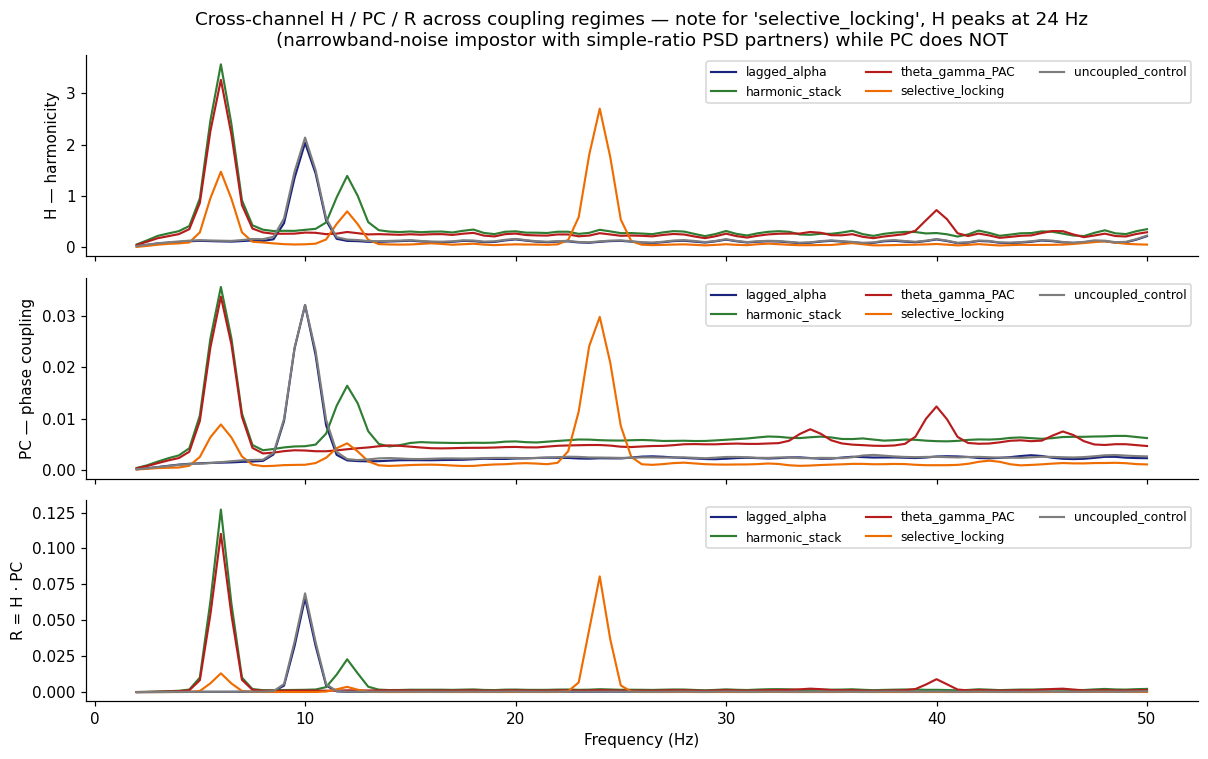


scenario                      top H peak       top PC peak        top R peak
---------------------------------------------------------------------------
lagged_alpha             10.0 Hz (2.038)   10.0 Hz (0.032)   10.0 Hz (0.065)
harmonic_stack            6.0 Hz (3.567)    6.0 Hz (0.036)    6.0 Hz (0.127)
theta_gamma_PAC           6.0 Hz (3.265)    6.0 Hz (0.034)    6.0 Hz (0.110)
selective_locking        24.0 Hz (2.703)   24.0 Hz (0.030)   24.0 Hz (0.081)
uncoupled_control        10.0 Hz (2.140)   10.0 Hz (0.032)   10.0 Hz (0.069)

For 'selective_locking', H's 24 Hz contribution from the narrowband-noise
impostor is visible — PC tells the truth: no actual coupling there.


In [15]:
cfg_xc = ResonanceConfig(precision_hz=0.5, fmin=2, fmax=50, noverlap=400)

results = {}
for name, (a, b) in SCENARIOS.items():
    results[name] = compute_cross_resonance(a, b, sf=SF, config=cfg_xc)

# Stacked H / PC / R panel comparison (symmetric 'all' flavor)
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
colors = ['#1a237e', '#2e7d32', '#b71c1c', '#ef6c00', '#7d7d7d']
for ax, (lbl, factor_key) in zip(axes, [
    ('H — harmonicity',      'H'),
    ('PC — phase coupling',  'PC'),
    ('R = H · PC',           None),  # None means resonance_spectrum
]):
    for (name, r), color in zip(results.items(), colors):
        vals = r.resonance_spectrum['all'] if factor_key is None else r.factors[factor_key]['all']
        ax.plot(r.freqs, vals, label=name, color=color, lw=1.4)
    ax.set_ylabel(lbl)
    ax.legend(loc='upper right', fontsize=8, ncols=3)
axes[-1].set_xlabel("Frequency (Hz)")
axes[0].set_title("Cross-channel H / PC / R across coupling regimes — note for 'selective_locking', H peaks at 24 Hz\n"
                   "(narrowband-noise impostor with simple-ratio PSD partners) while PC does NOT")
plt.tight_layout(); plt.show()

# Numeric table: which frequencies dominate H vs PC vs R, per scenario?
print()
print(f"{'scenario':<22}  {'top H peak':>16}  {'top PC peak':>16}  {'top R peak':>16}")
print("-" * 75)
for name, r in results.items():
    H = r.factors['H']['all']
    PC = r.factors['PC']['all']
    R = r.resonance_spectrum['all']
    f_H  = r.freqs[int(np.argmax(H))]
    f_PC = r.freqs[int(np.argmax(PC))]
    f_R  = r.freqs[int(np.argmax(R))]
    print(f"{name:<22}  {f'{f_H:.1f} Hz ({H.max():.3f})':>16}  "
          f"{f'{f_PC:.1f} Hz ({PC.max():.3f})':>16}  "
          f"{f'{f_R:.1f} Hz ({R.max():.3f})':>16}")
print()
print("For 'selective_locking', H's 24 Hz contribution from the narrowband-noise")
print("impostor is visible — PC tells the truth: no actual coupling there.")


### 9c. Cross-resonance MATRICES — what the spectra throw away

The H(f) and PC(f) spectra are reductions of the full **N × N cross-frequency
matrices**, where entry `[i, j]` = (similarity / phase coupling) between
channel-1 frequency bin `i` and channel-2 frequency bin `j`. The spectra
collapse columns away. For diagnostics — and especially for cross-frequency
coupling — it pays to inspect the matrices directly via `result.intermediates`.


H matrix shape:  (97, 97)
PC matrix shape: (97, 97)


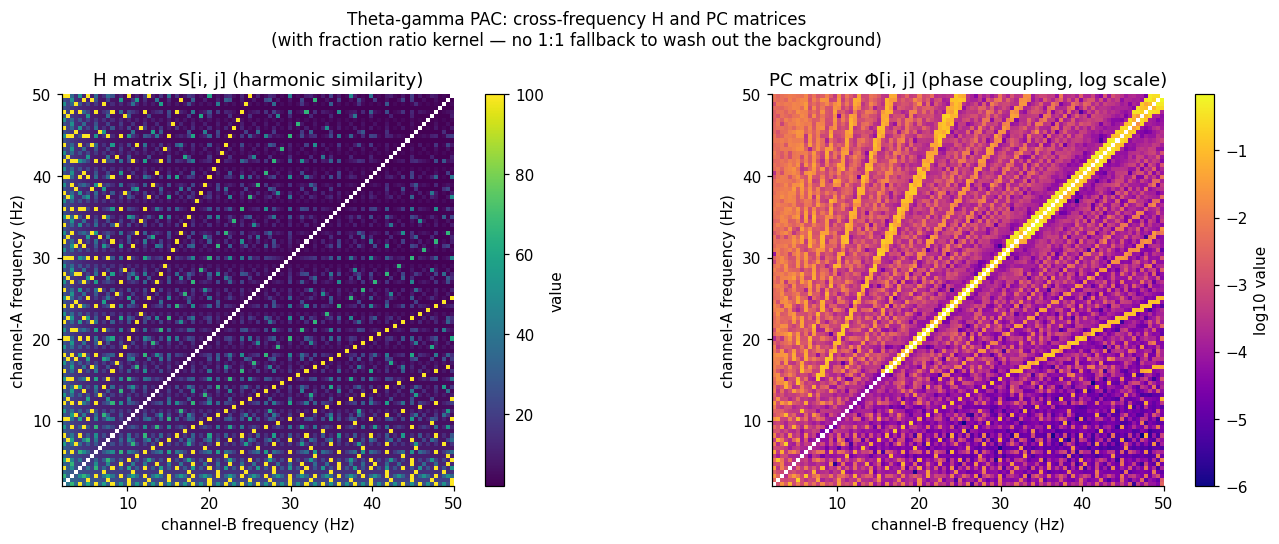


Reading the H matrix: bright cells line up along simple-ratio bands radiating
from the diagonal (the 1:2 ridge, 1:3 ridge, etc.) — that's the harmonic
similarity grid. The diagonal is masked.

Reading the PC matrix (log10): the dominant hot spot is the (6 Hz, 12 Hz)
region where the shared theta drives a 1:2 phase lock. The vertical band
around 40 Hz on channel B shows cross-frequency phase coupling between
channel A's theta and channel B's gamma envelope — the theta-gamma PAC.


In [16]:
# Re-run on theta-gamma PAC with the FRACTION ratio kernel.
# This is important: the default 'binary' kernel with fallback_to_1_1=True
# fills Phi[i,j] for EVERY frequency pair (testing 1:1 coupling at non-matching
# pairs), which washes out the heatmap. The 'fraction' kernel returns the
# exact (n, m) for the closest rational and weights via Tenney height — so
# simple-ratio cells stand out cleanly against an exponentially suppressed
# background of complex ratios.
a, b = SCENARIOS['theta_gamma_PAC']
cfg_keep = ResonanceConfig(
    precision_hz=0.5, fmin=2, fmax=50, noverlap=400,
    ratio_kernel='fraction',
    ratio_kernel_params={'max_denom': 16, 'beta': 1.0},
    coupling_metric='nm_plv_canonical',
    return_intermediates=True,
)
r_pac = compute_cross_resonance(a, b, sf=SF, config=cfg_keep)
# With return_intermediates=True, the N×N matrices are accessible as typed
# properties on the result — no dictionary fishing required.
H_mat  = r_pac.harmonicity_matrix
PC_mat = r_pac.phase_coupling_matrix
print(f"H matrix shape:  {H_mat.shape}")
print(f"PC matrix shape: {PC_mat.shape}")

freqs = r_pac.freqs

def _heatmap(ax, M, title, cmap='viridis', vmax=None, log=False):
    M_show = M.copy().astype(float)
    np.fill_diagonal(M_show, np.nan)                     # mask self-pair
    if log:
        # log scale for highly skewed Tenney-weighted matrix
        with np.errstate(divide='ignore'):
            M_show = np.log10(np.clip(M_show, 1e-6, None))
        cb_label = 'log10 value'
    else:
        cb_label = 'value'
    finite = M_show[np.isfinite(M_show)]
    vmin = float(np.nanmin(finite)) if finite.size else 0.0
    if vmax is None:
        vmax = float(np.nanmax(finite)) if finite.size else 1.0
    im = ax.imshow(M_show, origin='lower', cmap=cmap, aspect='equal',
                    vmin=vmin, vmax=vmax,
                    extent=[freqs[0], freqs[-1], freqs[0], freqs[-1]])
    ax.set_xlabel('channel-B frequency (Hz)')
    ax.set_ylabel('channel-A frequency (Hz)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, label=cb_label)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
_heatmap(axes[0], H_mat,  'H matrix S[i, j] (harmonic similarity)',          cmap='viridis')
_heatmap(axes[1], PC_mat, 'PC matrix Φ[i, j] (phase coupling, log scale)',   cmap='plasma', log=True)
fig.suptitle('Theta-gamma PAC: cross-frequency H and PC matrices\n'
              '(with fraction ratio kernel — no 1:1 fallback to wash out the background)',
              fontsize=11)
plt.tight_layout(); plt.show()
print()
print("Reading the H matrix: bright cells line up along simple-ratio bands radiating")
print("from the diagonal (the 1:2 ridge, 1:3 ridge, etc.) — that's the harmonic")
print("similarity grid. The diagonal is masked.")
print()
print("Reading the PC matrix (log10): the dominant hot spot is the (6 Hz, 12 Hz)")
print("region where the shared theta drives a 1:2 phase lock. The vertical band")
print("around 40 Hz on channel B shows cross-frequency phase coupling between")
print("channel A's theta and channel B's gamma envelope — the theta-gamma PAC.")


### 9d. Directional flavors — `1to2` vs `2to1` vs `all`

For an **asymmetric** coupling like theta-gamma PAC (channel B carries an
extra cross-frequency lock that channel A does not), the three reducer
flavors expose directional information that the symmetric `'all'` average
loses.


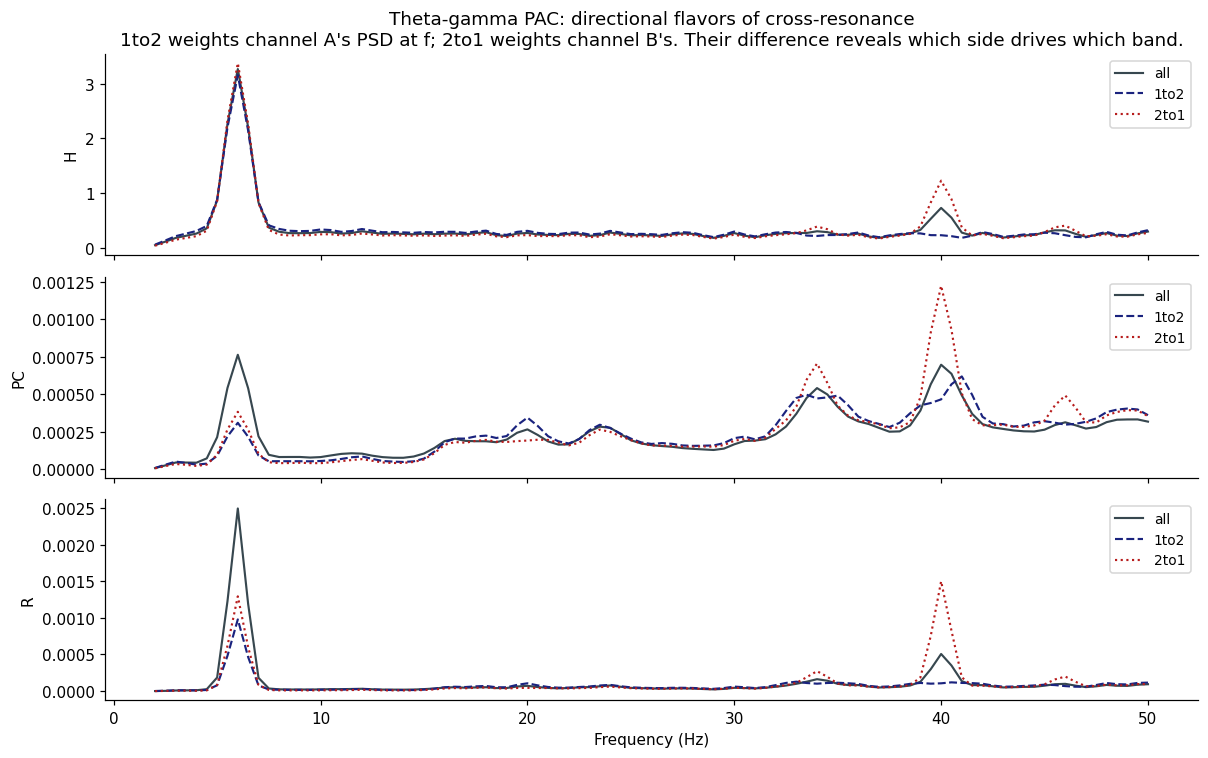


Directional asymmetry index (1to2 - 2to1) / (1to2 + 2to1):
    6 Hz   1to2=0.0010  2to1=0.0013  asymmetry=-0.139
   12 Hz   1to2=0.0000  2to1=0.0000  asymmetry=+0.249
   40 Hz   1to2=0.0001  2to1=0.0015  asymmetry=-0.868


In [17]:
# Same theta-gamma PAC result
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, (lbl, factor) in zip(axes, [
    ('H', 'H'), ('PC', 'PC'), ('R', None),
]):
    for flavor, ls, color in [('all', '-', '#37474f'),
                                ('1to2', '--', '#1a237e'),
                                ('2to1', ':',  '#b71c1c')]:
        vals = (r_pac.resonance_spectrum[flavor] if factor is None
                else r_pac.factors[factor][flavor])
        ax.plot(r_pac.freqs, vals, ls=ls, color=color, lw=1.4, label=flavor)
    ax.set_ylabel(lbl)
    ax.legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel("Frequency (Hz)")
axes[0].set_title("Theta-gamma PAC: directional flavors of cross-resonance\n"
                   "1to2 weights channel A's PSD at f; 2to1 weights channel B's. "
                   "Their difference reveals which side drives which band.")
plt.tight_layout(); plt.show()

# Directional asymmetry index at key frequencies
print()
print("Directional asymmetry index (1to2 - 2to1) / (1to2 + 2to1):")
for f0 in [6, 12, 40]:
    i = int(np.argmin(np.abs(r_pac.freqs - f0)))
    a12 = r_pac.resonance_spectrum['1to2'][i]
    a21 = r_pac.resonance_spectrum['2to1'][i]
    denom = a12 + a21
    asym = (a12 - a21) / denom if denom > 0 else 0.0
    print(f"  {f0:>3} Hz   1to2={a12:.4f}  2to1={a21:.4f}  asymmetry={asym:+.3f}")


### 9e. Surrogate-normalized cross-resonance

The same surrogate-normalization story as Section 8, applied to cross-channel
data. Here, we use `compute_cross_resonance_connectivity_zscore` from the
multi-channel API but on a 2-row matrix to make the comparison explicit:
how much of the observed coupling survives a null that preserves each
channel's PSD but destroys their cross-channel phase relation?


In [18]:
# Use the harmonic-stack scenario (cleanest signal-vs-noise)
a, b = SCENARIOS['harmonic_stack']
data_2ch = np.stack([a, b])

hc2 = harmonic_connectivity(
    sf=SF, data=data_2ch, peaks_function='FOOOF',
    precision=0.5, n_harm=5, min_freq=2, max_freq=30, n_peaks=4,
)

obs, z, p = hc2.compute_cross_resonance_connectivity_zscore(
    config=cfg_xc, factor='R', flavor='all', aggregate='peak_to_median',
    surrogate_kind='iaaft', n_surrogates=20, rng_seed=42, graph=False,
)
print(f"Observed R aggregate (off-diagonal): {obs[0,1]:.4f}")
print(f"z-score vs IAAFT null:               {z[0,1]:.2f}")
print(f"Empirical p-value:                   {p[0,1]:.4f}")
print()

# Compare against uncoupled control
a, b = SCENARIOS['uncoupled_control']
data_2ch_uc = np.stack([a, b])
hc2_uc = harmonic_connectivity(
    sf=SF, data=data_2ch_uc, peaks_function='FOOOF',
    precision=0.5, n_harm=5, min_freq=2, max_freq=30, n_peaks=4,
)
obs2, z2, p2 = hc2_uc.compute_cross_resonance_connectivity_zscore(
    config=cfg_xc, factor='R', flavor='all', aggregate='peak_to_median',
    surrogate_kind='iaaft', n_surrogates=20, rng_seed=42, graph=False,
)
print("Same metric on uncoupled control:")
print(f"  Observed: {obs2[0,1]:.4f}   z: {z2[0,1]:.2f}   p: {p2[0,1]:.4f}")
print()
print("z-score discriminates real coupling from same-PSD chance.")


C:\Users\skite\Documents\Github\biotuner\.claude\worktrees\sweet-hamilton-6c0f0d\biotuner\harmonic_connectivity.py:949: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(surr_stack, axis=0)
C:\Users\skite\miniconda3\envs\py310\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Observed R aggregate (off-diagonal): 1.8819
z-score vs IAAFT null:               0.27
Empirical p-value:                   0.3810



Same metric on uncoupled control:
  Observed: 2.3822   z: 0.28   p: 0.3810

z-score discriminates real coupling from same-PSD chance.


## 10. Connectivity matrices on multi-channel data

Use the `harmonic_connectivity` class for N-channel analyses. It exposes both
the legacy peak-based methods and the new spectrum-based ones.


In [19]:
# Build a 4-channel synthetic dataset
def build_4ch_data(sf=SF, duration=8.0):
    t = np.arange(int(sf * duration)) / sf
    rng = np.random.default_rng(0)
    noise = lambda seed: 0.25 * pink_noise(len(t), sf, seed=seed)
    return np.stack([
        np.sin(2*np.pi*10*t)          + noise(1),  # e1: clean 10 Hz
        np.sin(2*np.pi*10*t + np.pi/4) + noise(2),  # e2: 10 Hz phase-locked to e1
        np.sin(2*np.pi*20*t + np.pi/8) + noise(3),  # e3: 1:2 harmonic of e1
        np.sin(2*np.pi*17*t + 1.7)     + noise(4),  # e4: independent
    ])

data = build_4ch_data()

hc = harmonic_connectivity(
    sf=SF, data=data, peaks_function='FOOOF',
    precision=0.5, n_harm=5, min_freq=2, max_freq=30, n_peaks=3,
)
print("data shape:", data.shape)


data shape: (4, 4000)


### 10a. Peak-based connectivity (legacy + new)


C:\Users\skite\miniconda3\envs\py310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\skite\miniconda3\envs\py310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\skite\miniconda3\envs\py310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\skite\miniconda3\envs\py310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\skite\miniconda3\envs\py310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\skite\miniconda3\envs\py310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value enco

C:\Users\skite\miniconda3\envs\py310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\skite\miniconda3\envs\py310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\skite\miniconda3\envs\py310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\skite\miniconda3\envs\py310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\skite\miniconda3\envs\py310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\skite\miniconda3\envs\py310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value enco

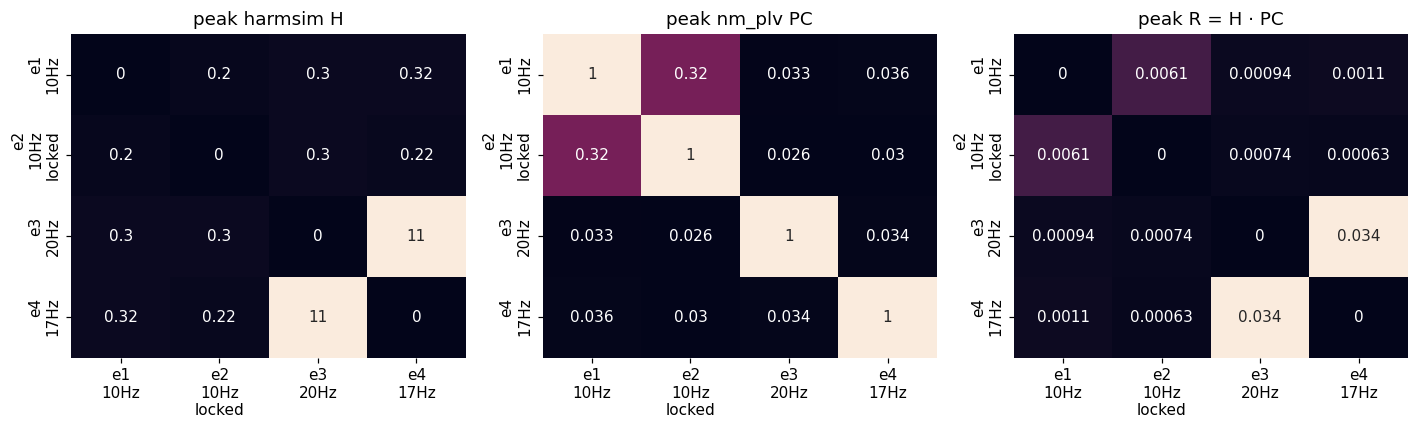

In [20]:
# Legacy peak-based H: harmsim
M_harmsim = hc.compute_harm_connectivity(metric='harmsim', graph=False)

# New: peak-based phase coupling (registry-dispatched)
M_pc = hc.compute_peak_phase_coupling_connectivity(
    coupling_metric='nm_plv', graph=False,
)

# New: peak-based H × PC = R
M_r = hc.compute_peak_resonance_connectivity(
    harm_metric='harmsim', coupling_metric='nm_plv', combine='product',
    graph=False,
)

import seaborn as sns
labels = ['e1\n10Hz', 'e2\n10Hz\nlocked', 'e3\n20Hz', 'e4\n17Hz']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, M, title in zip(axes, [M_harmsim, M_pc, M_r],
                         ['peak harmsim H', 'peak nm_plv PC', 'peak R = H · PC']):
    sns.heatmap(np.nan_to_num(M), ax=ax, annot=True, fmt='.2g',
                xticklabels=labels, yticklabels=labels, cbar=False)
    ax.set_title(title)
plt.tight_layout(); plt.show()


### 10b. Spectrum-based cross-resonance matrix


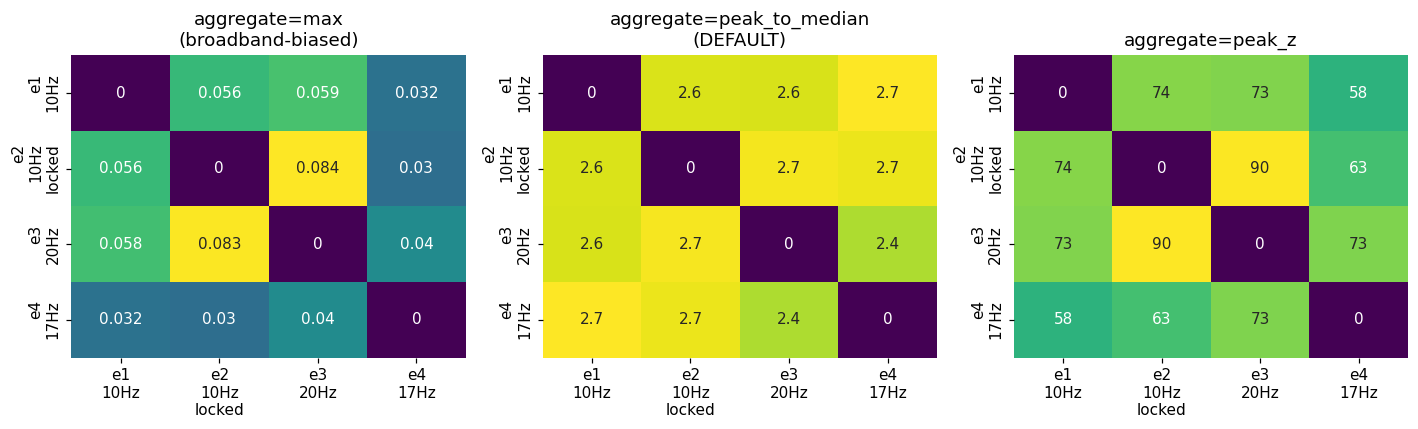

In [21]:
# Spectrum-based: loop compute_cross_resonance over all pairs
cfg = ResonanceConfig(precision_hz=0.5, fmin=2, fmax=30)

M_max = hc.compute_cross_resonance_connectivity(
    config=cfg, factor='R', flavor='all', aggregate='max', graph=False,
)
M_p2m = hc.compute_cross_resonance_connectivity(
    config=cfg, factor='R', flavor='all', aggregate='peak_to_median', graph=False,
)
M_pz = hc.compute_cross_resonance_connectivity(
    config=cfg, factor='R', flavor='all', aggregate='peak_z', graph=False,
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, M, title in zip(axes, [M_max, M_p2m, M_pz],
                         ['aggregate=max\n(broadband-biased)',
                          'aggregate=peak_to_median\n(DEFAULT)',
                          'aggregate=peak_z']):
    sns.heatmap(np.nan_to_num(M), ax=ax, annot=True, fmt='.2g',
                xticklabels=labels, yticklabels=labels, cbar=False,
                cmap='viridis')
    ax.set_title(title)
plt.tight_layout(); plt.show()


### 10c. Statistical inference: surrogate-z-scored connectivity matrix

For paper-quality discrimination between true cross-channel phase coupling and
broadband-power artifacts, run the connectivity matrix against an
**IAAFT** surrogate null (preserves per-channel PSD, destroys cross-channel
phase). High z-scores = real coupling above the broadband baseline.


C:\Users\skite\Documents\Github\biotuner\.claude\worktrees\sweet-hamilton-6c0f0d\biotuner\harmonic_connectivity.py:949: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(surr_stack, axis=0)
C:\Users\skite\miniconda3\envs\py310\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


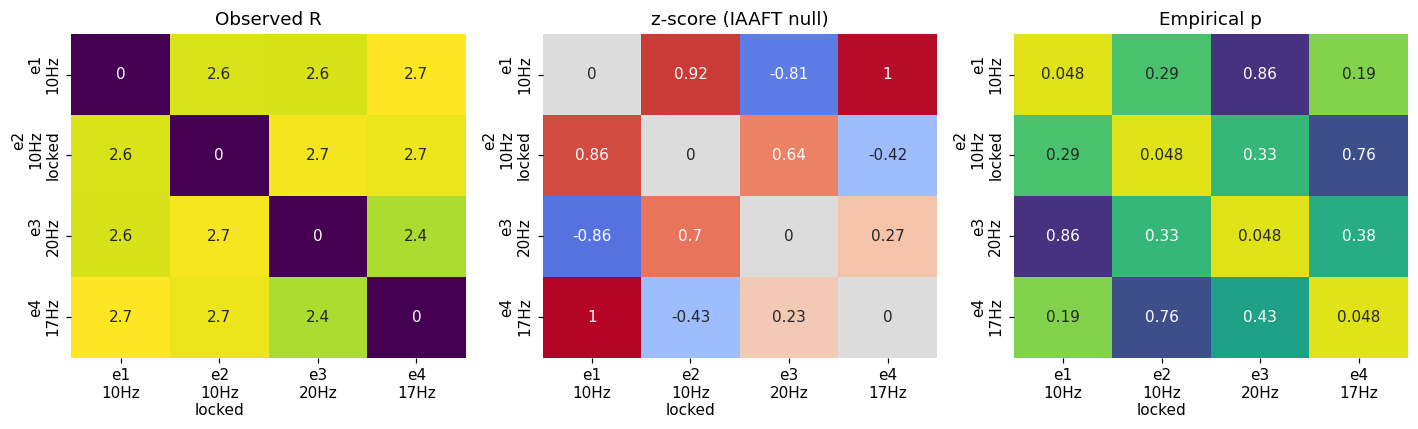

In [22]:
obs, z_matrix, p_matrix = hc.compute_cross_resonance_connectivity_zscore(
    config=cfg, factor='R', flavor='all', aggregate='peak_to_median',
    surrogate_kind='iaaft', n_surrogates=20, rng_seed=42,
    graph=False,
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, M, title, cmap, kw in [
    (axes[0], obs, "Observed R", "viridis", {}),
    (axes[1], z_matrix, "z-score (IAAFT null)", "coolwarm", {"center": 0}),
    (axes[2], p_matrix, "Empirical p", "viridis_r", {"vmin": 0, "vmax": 1}),
]:
    sns.heatmap(np.nan_to_num(M), ax=ax, annot=True, fmt='.2g',
                xticklabels=labels, yticklabels=labels, cbar=False,
                cmap=cmap, **kw)
    ax.set_title(title)
plt.tight_layout(); plt.show()


## 11. Reproducing legacy `compute_global_harmonicity`

Existing analyses that used the pre-refactor `compute_global_harmonicity`
reproduce bit-exactly by passing the **legacy preset** ResonanceConfig.


In [23]:
# Build a legacy-equivalent ResonanceConfig
legacy_cfg = ResonanceConfig(
    psd_normalization='minmax_prob',           # legacy two-step PSD norm
    harmonic_kernel='harmsim',
    harmonic_kernel_params={'n_harms': 10, 'delta_lim': 20, 'min_notes': 2},
    ratio_kernel='binary',
    ratio_kernel_params={'max_nm': 3, 'tolerance': 0.05, 'fallback_to_1_1': True},
    phase_estimator='stft',
    coupling_metric='nm_plv',                  # legacy convention
    gaussian_smooth_sigma=1.0,
    legacy_self_pair_subtract=True,
    normalize=True, bandwidth_correction=False,
    combine='product',
)

sig = harmonic_signal()
result_legacy = compute_resonance(sig, sf=SF, config=legacy_cfg)
print("This reproduces the pre-refactor compute_global_harmonicity numerics "
      "within float-precision.")
print("Recommended for: reproducing published paper outputs only.")


This reproduces the pre-refactor compute_global_harmonicity numerics within float-precision.
Recommended for: reproducing published paper outputs only.


For **new analyses**, the recommended config is the default:

```python
result = compute_resonance(signal, sf=1000)
```

which uses the refined defaults (joint PC reducer, n:m ratio kernel where
applicable, `nm_plv_canonical`-compatible conventions).

---

## Further reading

- **Module docstrings** — `help(biotuner.resonance)`, `help(biotuner.harmonic_spectrum)`,
  `help(biotuner.harmonic_connectivity)` — each has a Quick Start.
- **`list_strategies()`** — discoverable inventory of every registered kernel,
  metric, and combine rule.
- **Sphinx API docs** — under `docs/api/resonance.rst`,
  `docs/api/harmonic_spectrum.rst`, `docs/api/harmonic_connectivity.rst`.
- **Plan** — `biotuner_resonance_plan.md` documents the full Phase 1 / 2 / 3
  roadmap and references for every algorithm.

### What's not in this notebook (Phase 2/3 additions)

The registry slots exist for these but aren't filled yet:

- More harmonic kernels: `sethares`, `stolzenburg`, `hopf`, `lorentzian`,
  `harmonic_entropy`, plus the existing-but-not-wired biotuner metrics
  `tenney_height`, `euler`, `compute_consonance`, `integral_tenney_height`.
- More ratio kernels: `arnold_tongue` (soft Gaussian), `stern_brocot`.
- More phase estimators: `hilbert_bandpass`, `morlet_wavelet`.
- Higher-order coupling: `bplv` (triplet), `mplv` (N-ary), `cf_plm`, `gpla`.
- Persistence (Q-factor) axis: `lagged_coherence`, `lhac`, `fooof_bandwidth`.

Each lands as a one-line `register_*` call against the existing registry —
contributions welcome.
